<a href="https://colab.research.google.com/github/Akshitvats026/MNIST-Handwritten-Digit-Classification-System/blob/main/Case_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
model = Sequential([
    Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation='relu',padding='same'),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256,activation='relu'),
    Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train,y_train,epochs=20,validation_data=(X_test,y_test))

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.4844 - loss: 1.4175 - val_accuracy: 0.6297 - val_loss: 1.0348
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6751 - loss: 0.9266 - val_accuracy: 0.6997 - val_loss: 0.8625
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7416 - loss: 0.7344 - val_accuracy: 0.7206 - val_loss: 0.7991
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7853 - loss: 0.6080 - val_accuracy: 0.7294 - val_loss: 0.7778
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8261 - loss: 0.4985 - val_accuracy: 0.7463 - val_loss: 0.7558
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8585 - loss: 0.4011 - val_accuracy: 0.7385 - val_loss: 0.8780
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8868 - loss: 0.3209 - val_accuracy: 0.7304 - val_loss: 0.9623
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9099 - loss: 0.2523 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


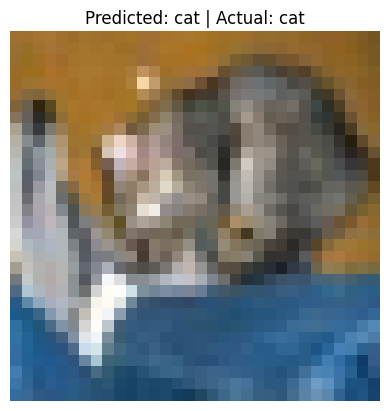

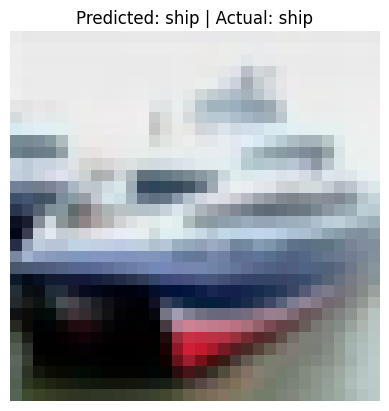

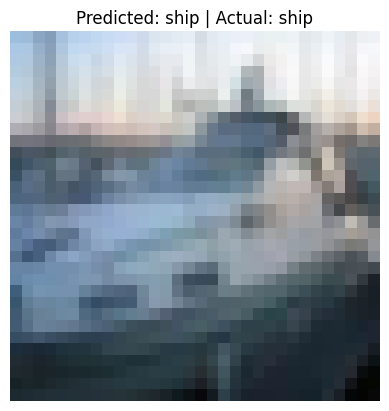

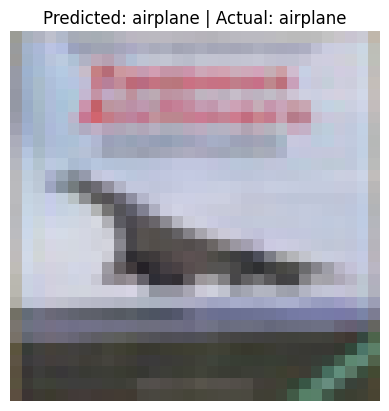

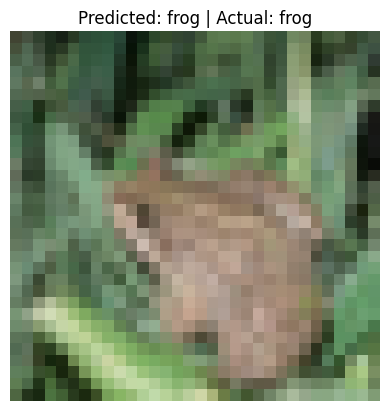

In [4]:
import matplotlib.pyplot as plt
import numpy as np

predictions = model.predict(X_test)


class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

for i in range(5):
    plt.imshow(X_test[i])
    plt.title("Predicted: " + class_names[np.argmax(predictions[i])] +
              " | Actual: " + class_names[np.argmax(y_test[i])])
    plt.axis('off')
    plt.show()